# TRAIL Error Type Distribution Analysis

Examines error type distributions across:
- **Full dataset** (all 148 traces, GAIA + SWE bench combined)
- **Train / Val / Test splits** (80/10/10 by trace_id)

Two perspectives per split:
1. **Co-occurrence count** — total annotated error spans (a trace with 5 Formatting Errors contributes 5)
2. **Trace-level presence** — number of traces where each error type appears at least once
3. **Root error distribution** — which error type is labelled as root (first annotation) per trace

In [1]:
import json
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

BENCH = os.path.join(os.path.dirname(os.path.abspath('.')), 'trail-benchmark', 'benchmarking')
# Adjust if running from a different cwd
if not os.path.isdir(BENCH):
    BENCH = 'benchmarking'

GAIA_DIR  = os.path.join(BENCH, 'processed_annotations_gaia')
SWE_DIR   = os.path.join(BENCH, 'processed_annotations_swe_bench')
SPLIT_DIR = os.path.join(BENCH, 'graph', 'splits', 'outputs')

print(f'BENCH: {BENCH}')
print(f'GAIA dir exists:  {os.path.isdir(GAIA_DIR)}')
print(f'SWE dir exists:   {os.path.isdir(SWE_DIR)}')
print(f'Split dir exists: {os.path.isdir(SPLIT_DIR)}')

BENCH: /data/wang/junh/githubs/trail-benchmark/benchmarking
GAIA dir exists:  True
SWE dir exists:   True
Split dir exists: True


In [2]:
# ── Load all annotations ────────────────────────────────────────────────────

def load_annotations(gaia_dir, swe_dir):
    """Returns {trace_id: {'errors': [...], 'benchmark': 'GAIA'|'SWE'}}."""
    data = {}
    for ann_dir, bmark, use_fname_id in [
        (gaia_dir, 'GAIA', True),
        (swe_dir,  'SWE',  False),
    ]:
        files = sorted(f for f in os.listdir(ann_dir)
                       if f.endswith('.json') and not f.startswith('old_'))
        for fname in files:
            with open(os.path.join(ann_dir, fname)) as f:
                ann = json.load(f)
            tid = os.path.splitext(fname)[0] if use_fname_id else ann.get('trace_id', os.path.splitext(fname)[0])
            errors = [e['category'].strip() for e in ann.get('errors', [])]
            if errors:
                data[tid] = {'errors': errors, 'benchmark': bmark}
    return data

traces = load_annotations(GAIA_DIR, SWE_DIR)
print(f'Total traces: {len(traces)}')
print(f'  GAIA: {sum(1 for v in traces.values() if v["benchmark"]=="GAIA")}')
print(f'  SWE:  {sum(1 for v in traces.values() if v["benchmark"]=="SWE")}')

Total traces: 144
  GAIA: 114
  SWE:  30


In [3]:
# ── Load splits ──────────────────────────────────────────────────────────────

def load_ids(split_dir, name):
    with open(os.path.join(split_dir, f'{name}_trace_ids.json')) as f:
        return set(json.load(f))

train_ids = load_ids(SPLIT_DIR, 'train')
val_ids   = load_ids(SPLIT_DIR, 'val')
test_ids  = load_ids(SPLIT_DIR, 'test')

with open(os.path.join(SPLIT_DIR, 'root_labels.json')) as f:
    root_labels = json.load(f)

print(f'train={len(train_ids)}  val={len(val_ids)}  test={len(test_ids)}')
assert train_ids.isdisjoint(val_ids) and train_ids.isdisjoint(test_ids) and val_ids.isdisjoint(test_ids)
print('Disjointness check: OK')

train=116  val=14  test=14
Disjointness check: OK


In [4]:
# ── Build summary DataFrames ─────────────────────────────────────────────────

ALL_CATS = sorted(set(cat for v in traces.values() for cat in v['errors']))
SPLITS   = {'all': set(traces.keys()), 'train': train_ids, 'val': val_ids, 'test': test_ids}
SPLIT_ORDER = ['all', 'train', 'val', 'test']

def build_counts(traces, id_set):
    """span_count, trace_presence, root_count per category for traces in id_set."""
    span   = defaultdict(int)
    pres   = defaultdict(int)
    root_c = defaultdict(int)
    for tid in id_set:
        if tid not in traces:
            continue
        errors = traces[tid]['errors']
        for cat in errors:
            span[cat] += 1
        for cat in set(errors):
            pres[cat] += 1
        root_c[root_labels.get(tid, errors[0])] += 1
    return span, pres, root_c

rows = []
for split, ids in SPLITS.items():
    span, pres, root_c = build_counts(traces, ids)
    n_traces = len([t for t in ids if t in traces])
    for cat in ALL_CATS:
        rows.append({
            'split':          split,
            'category':       cat,
            'span_count':     span.get(cat, 0),
            'trace_presence': pres.get(cat, 0),
            'root_count':     root_c.get(cat, 0),
            'n_traces':       n_traces,
        })

df = pd.DataFrame(rows)
df['span_pct']   = df['span_count']     / df.groupby('split')['span_count'].transform('sum') * 100
df['pres_pct']   = df['trace_presence'] / df['n_traces'] * 100
df['root_pct']   = df['root_count']     / df.groupby('split')['root_count'].transform('sum') * 100

df_all = df[df['split'] == 'all'].set_index('category')
print(df[df['split']=='all'][['category','span_count','trace_presence','root_count']].to_string(index=False))

                        category  span_count  trace_presence  root_count
           Authentication Errors           5               5           1
       Context Handling Failures          49              44           3
        Environment Setup Errors           9               9           2
               Formatting Errors         197              74          45
                  Goal Deviation          65              64           5
Incorrect Problem Identification          28              20           2
      Instruction Non-compliance         156              78          41
                   Language-only          53              50           6
      Poor Information Retrieval          41              29           5
                  Resource Abuse          57              42           1
             Resource Exhaustion           3               3           0
              Resource Not Found           7               4           0
                  Service Errors           2       

In [5]:
# ── Helpers ──────────────────────────────────────────────────────────────────

COLORS = {
    'all':   '#4C72B0',
    'train': '#55A868',
    'val':   '#C44E52',
    'test':  '#DD8452',
}

# Short labels for x-axis
SHORT = {
    'Authentication Errors':        'Auth Err',
    'Context Handling Failures':    'Ctx Fail',
    'Environment Setup Errors':     'Env Setup',
    'Formatting Errors':            'Format',
    'Goal Deviation':               'Goal Dev',
    'Incorrect Problem Identification': 'Inc ProbID',
    'Instruction Non-compliance':   'Instr NC',
    'Language-only':                'Lang-only',
    'Poor Information Retrieval':   'Poor IR',
    'Resource Abuse':               'Res Abuse',
    'Resource Exhaustion':          'Res Exh',
    'Resource Not Found':           'Res NF',
    'Service Errors':               'Svc Err',
    'Task Orchestration':           'Task Orch',
    'Timeout Issues':               'Timeout',
    'Tool Definition Issues':       'Tool Def',
    'Tool Output Misinterpretation':'Tool OutMis',
    'Tool Selection Errors':        'Tool Sel',
    'Tool-related':                 'Tool-rel',
}
short_cats = [SHORT.get(c, c) for c in ALL_CATS]

## 1. Span-Count Distribution (before split)

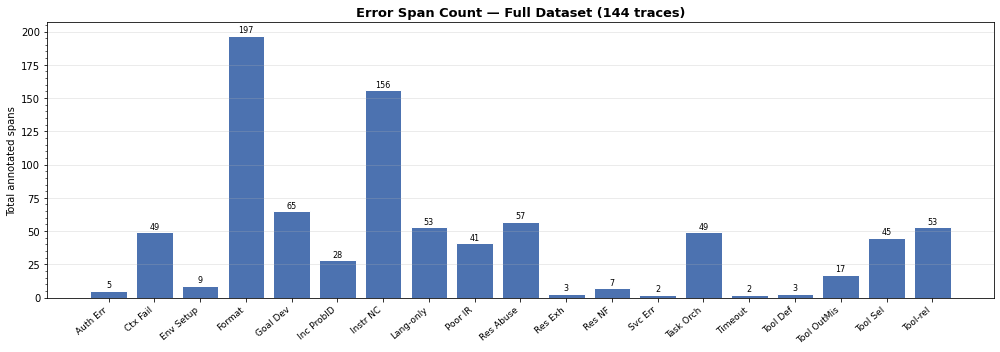

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

d_all = df[df['split']=='all'].set_index('category').reindex(ALL_CATS)
bars = ax.bar(short_cats, d_all['span_count'], color=COLORS['all'], edgecolor='white')

# Annotate counts
for bar, val in zip(bars, d_all['span_count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(val)), ha='center', va='bottom', fontsize=8)

ax.set_title('Error Span Count — Full Dataset (144 traces)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total annotated spans')
ax.set_xticks(range(len(ALL_CATS)))
ax.set_xticklabels(short_cats, rotation=40, ha='right', fontsize=9)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('error_span_count_full.png', dpi=150)
plt.show()

## 2. Span-Count Distribution — Train / Val / Test comparison

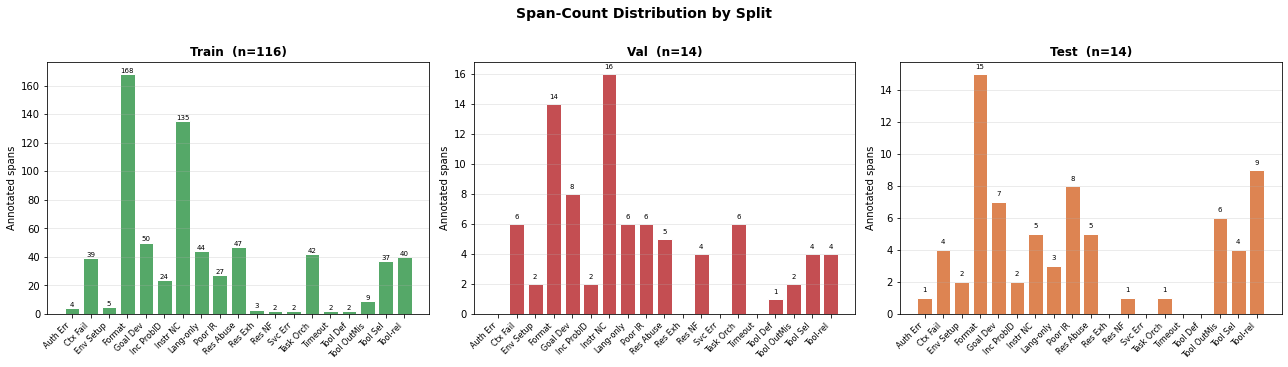

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, split in zip(axes, ['train', 'val', 'test']):
    d = df[df['split']==split].set_index('category').reindex(ALL_CATS)
    n = int(d['n_traces'].iloc[0])
    bars = ax.bar(short_cats, d['span_count'], color=COLORS[split], edgecolor='white')
    for bar, val in zip(bars, d['span_count']):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(int(val)), ha='center', va='bottom', fontsize=7)
    ax.set_title(f'{split.capitalize()}  (n={n})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Annotated spans')
    ax.set_xticks(range(len(ALL_CATS)))
    ax.set_xticklabels(short_cats, rotation=45, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Span-Count Distribution by Split', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('error_span_count_splits.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Trace-Level Presence — grouped bar (all 4 views)

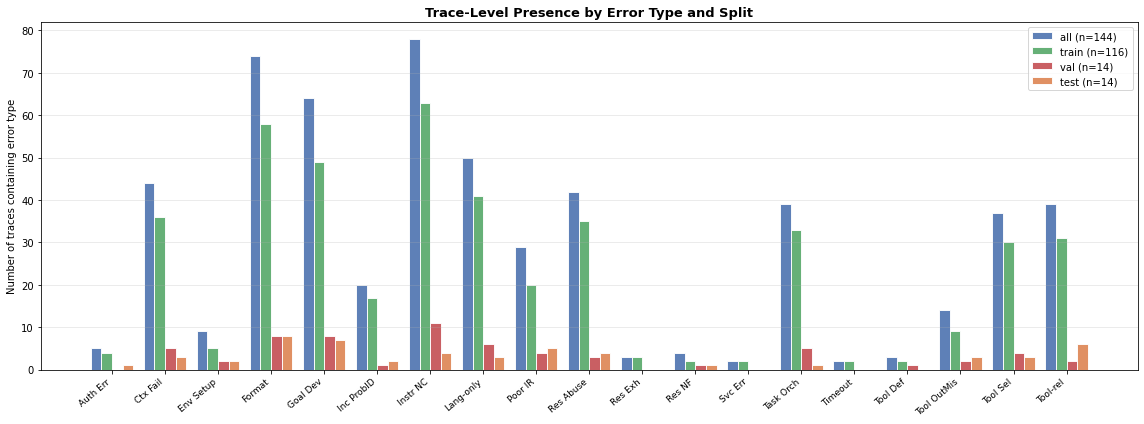

In [8]:
fig, ax = plt.subplots(figsize=(16, 6))

n_splits = len(SPLIT_ORDER)
x = np.arange(len(ALL_CATS))
total_w = 0.8
w = total_w / n_splits

for i, split in enumerate(SPLIT_ORDER):
    d = df[df['split']==split].set_index('category').reindex(ALL_CATS)
    offset = (i - (n_splits-1)/2) * w
    n = int(d['n_traces'].iloc[0])
    ax.bar(x + offset, d['trace_presence'], width=w,
           label=f'{split} (n={n})', color=COLORS[split], edgecolor='white', alpha=0.9)

ax.set_title('Trace-Level Presence by Error Type and Split', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of traces containing error type')
ax.set_xticks(x)
ax.set_xticklabels(short_cats, rotation=40, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('error_trace_presence_splits.png', dpi=150)
plt.show()

## 4. Relative Frequency (%) — span count, trace presence, root label

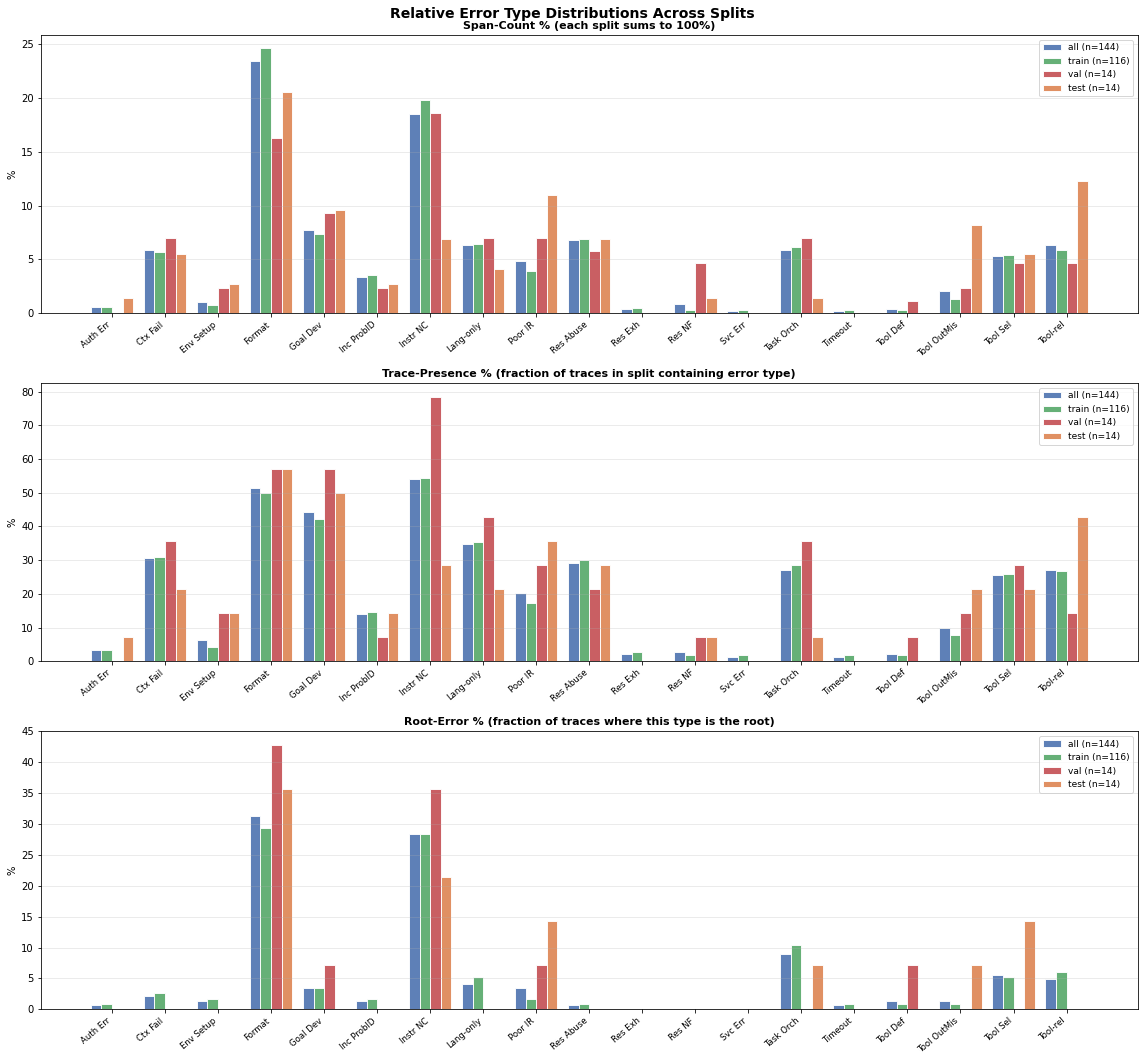

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 15))

metrics = [
    ('span_pct',   'Span-Count % (each split sums to 100%)'),
    ('pres_pct',   'Trace-Presence % (fraction of traces in split containing error type)'),
    ('root_pct',   'Root-Error % (fraction of traces where this type is the root)'),
]

x = np.arange(len(ALL_CATS))
n_splits = len(SPLIT_ORDER)
total_w = 0.8
w = total_w / n_splits

for ax, (metric, title) in zip(axes, metrics):
    for i, split in enumerate(SPLIT_ORDER):
        d = df[df['split']==split].set_index('category').reindex(ALL_CATS)
        offset = (i - (n_splits-1)/2) * w
        n = int(d['n_traces'].iloc[0])
        ax.bar(x + offset, d[metric], width=w,
               label=f'{split} (n={n})', color=COLORS[split], edgecolor='white', alpha=0.9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_xticks(x)
    ax.set_xticklabels(short_cats, rotation=40, ha='right', fontsize=8.5)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Relative Error Type Distributions Across Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('error_relative_distributions.png', dpi=150)
plt.show()

## 5. Root-Error Distribution (primary target for GCT model)

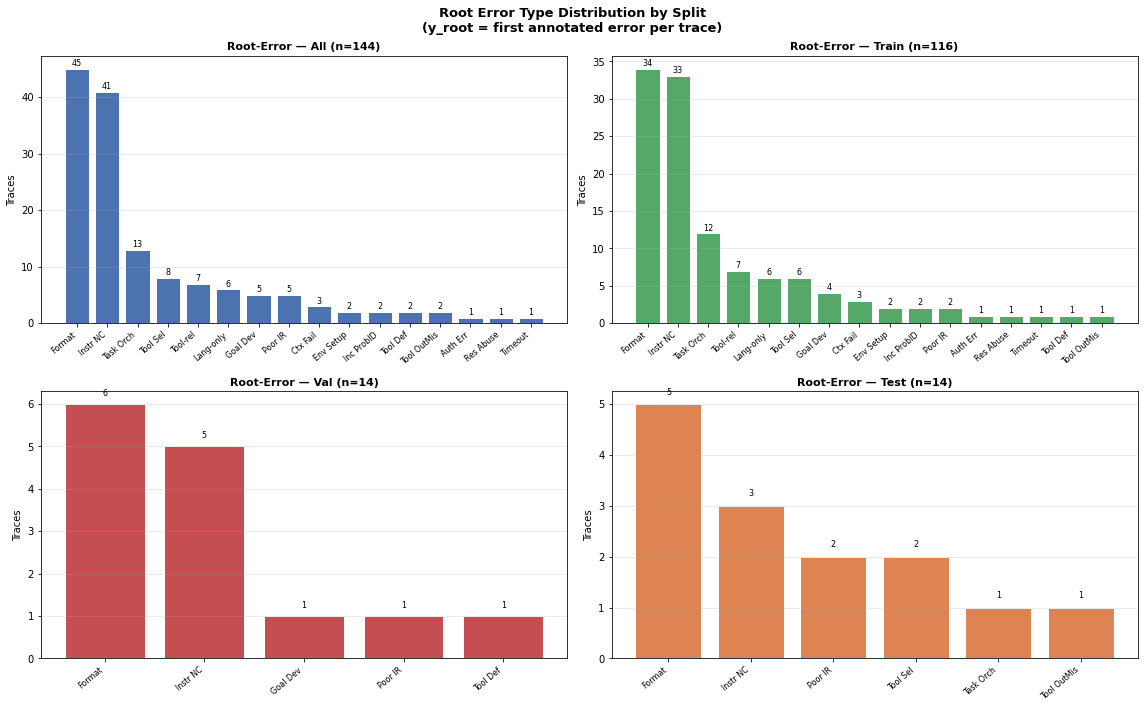

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, split in zip(axes.flat, SPLIT_ORDER):
    d = df[df['split']==split].set_index('category').reindex(ALL_CATS)
    n = int(d['n_traces'].iloc[0])
    nonzero = d['root_count'] > 0
    cats_nz  = [SHORT.get(c, c) for c, flag in zip(ALL_CATS, nonzero) if flag]
    vals_nz  = d.loc[nonzero, 'root_count'].values
    sort_idx = np.argsort(-vals_nz)
    bars = ax.bar(np.arange(len(cats_nz)), vals_nz[sort_idx],
                  color=COLORS[split], edgecolor='white')
    for bar, val in zip(bars, vals_nz[sort_idx]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                str(int(val)), ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Root-Error — {split.capitalize()} (n={n})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Traces')
    ax.set_xticks(range(len(cats_nz)))
    ax.set_xticklabels([cats_nz[i] for i in sort_idx], rotation=40, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Root Error Type Distribution by Split\n(y_root = first annotated error per trace)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('root_error_distribution.png', dpi=150)
plt.show()

## 6. Heatmap — Trace-Presence Fraction per Split

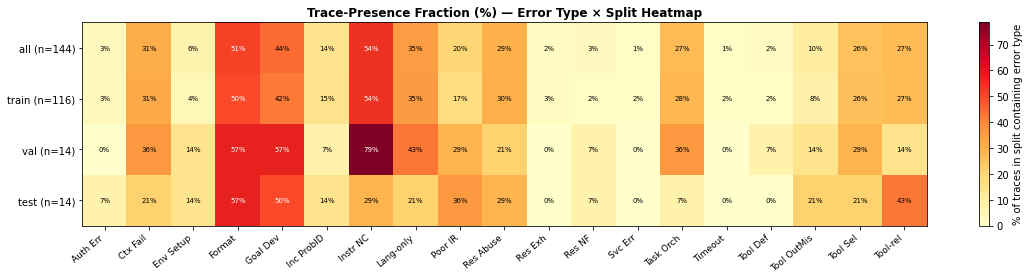

In [11]:
import matplotlib.colors as mcolors

heat_data = []
for split in SPLIT_ORDER:
    d = df[df['split']==split].set_index('category').reindex(ALL_CATS)
    heat_data.append(d['pres_pct'].values)

heat = np.array(heat_data)   # [4, 19]

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(heat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=heat.max())

ax.set_xticks(range(len(ALL_CATS)))
ax.set_xticklabels(short_cats, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(SPLIT_ORDER)))
ns = {s: len([t for t in SPLITS[s] if t in traces]) for s in SPLIT_ORDER}
ax.set_yticklabels([f'{s} (n={ns[s]})' for s in SPLIT_ORDER], fontsize=10)

# Annotate cells
for i in range(len(SPLIT_ORDER)):
    for j in range(len(ALL_CATS)):
        val = heat[i, j]
        color = 'white' if val > heat.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='% of traces in split containing error type')
ax.set_title('Trace-Presence Fraction (%) — Error Type × Split Heatmap',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('error_presence_heatmap.png', dpi=150)
plt.show()

## 7. Summary Table

In [12]:
pivot_span = df.pivot(index='category', columns='split', values='span_count')[SPLIT_ORDER]
pivot_pres = df.pivot(index='category', columns='split', values='trace_presence')[SPLIT_ORDER]
pivot_root = df.pivot(index='category', columns='split', values='root_count')[SPLIT_ORDER]

summary = pd.concat({
    'span_count':      pivot_span,
    'trace_presence':  pivot_pres,
    'root_count':      pivot_root,
}, axis=1)

# Flatten MultiIndex columns
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.astype(int)

# Highlight rare categories
rare = summary['trace_presence_all'] <= 5

display_cols = [
    'span_count_all', 'span_count_train', 'span_count_val', 'span_count_test',
    'trace_presence_all', 'trace_presence_train', 'trace_presence_val', 'trace_presence_test',
    'root_count_all', 'root_count_train', 'root_count_val', 'root_count_test',
]

def highlight_rare(row):
    if row.name in summary[rare].index:
        return ['background-color: #fff3cd'] * len(row)
    return [''] * len(row)

(
    summary[display_cols]
    .sort_values('span_count_all', ascending=False)
    .style
    .apply(highlight_rare, axis=1)
    .set_caption('Yellow = rare categories (≤5 traces total). '
                 'Columns: span_count | trace_presence | root_count  ×  all/train/val/test')
    .format('{:d}')
)

,span_count_all,span_count_train,span_count_val,span_count_test,trace_presence_all,trace_presence_train,trace_presence_val,trace_presence_test,root_count_all,root_count_train,root_count_val,root_count_test
category,,,,,,,,,,,,
Formatting Errors,197,168,14,15,74,58,8,8,45,34,6,5
Instruction Non-compliance,156,135,16,5,78,63,11,4,41,33,5,3
Goal Deviation,65,50,8,7,64,49,8,7,5,4,1,0
Resource Abuse,57,47,5,5,42,35,3,4,1,1,0,0
Language-only,53,44,6,3,50,41,6,3,6,6,0,0
Tool-related,53,40,4,9,39,31,2,6,7,7,0,0
Context Handling Failures,49,39,6,4,44,36,5,3,3,3,0,0
Task Orchestration,49,42,6,1,39,33,5,1,13,12,0,1
Tool Selection Errors,45,37,4,4,37,30,4,3,8,6,0,2


In [13]:
# Print class-imbalance ratio for root prediction task
root_all = df[df['split']=='all'].set_index('category')['root_count'].sort_values(ascending=False)
total_root = root_all.sum()
print(f'Root-error class imbalance (full dataset, n={total_root})')
print(f'{"Category":<40} {"Count":>6}  {"Frac":>7}  {"Ratio (vs min)":>15}')
print('-' * 75)
min_nonzero = root_all[root_all > 0].min()
for cat, cnt in root_all.items():
    if cnt == 0:
        continue
    ratio = cnt / min_nonzero
    print(f'{cat:<40} {int(cnt):>6}  {cnt/total_root:>7.1%}  {ratio:>15.1f}x')

Root-error class imbalance (full dataset, n=144)
Category                                  Count     Frac   Ratio (vs min)
---------------------------------------------------------------------------
Formatting Errors                            45    31.2%             45.0x
Instruction Non-compliance                   41    28.5%             41.0x
Task Orchestration                           13     9.0%             13.0x
Tool Selection Errors                         8     5.6%              8.0x
Tool-related                                  7     4.9%              7.0x
Language-only                                 6     4.2%              6.0x
Goal Deviation                                5     3.5%              5.0x
Poor Information Retrieval                    5     3.5%              5.0x
Context Handling Failures                     3     2.1%              3.0x
Environment Setup Errors                      2     1.4%              2.0x
Incorrect Problem Identification              2    